# Análisis Lingüístico y Jerárquico de Datos CIE-10 y CODIESP

Este notebook realiza un análisis exhaustivo de las características lingüísticas de las descripciones médicas en los conjuntos de datos CIE-10-ES (diagnósticos, procedimientos y químicos) y CODIESP, así como un estudio de la estructura jerárquica de los códigos CIE-10.

## Objetivos del Análisis

1. **Análisis Lingüístico**: 
   - Identificar patrones lingüísticos en las descripciones médicas
   - Calcular métricas de complejidad lingüística
   - Analizar n-gramas y colocaciones significativas

2. **Análisis Jerárquico**:
   - Modelar la estructura jerárquica de los códigos CIE-10
   - Visualizar relaciones entre códigos padre-hijo
   - Estudiar la distribución de códigos por nivel jerárquico

3. **Análisis Comparativo**:
   - Comparar vocabularios entre CIE-10-ES y CODIESP
   - Evaluar diferencias en complejidad lingüística
   - Identificar palabras comunes y exclusivas de cada conjunto

La documentación completa de este análisis se puede encontrar en:
`data_analysis/DOCUMENTATION_LINGUISTICO_JERARQUICO.md`

In [16]:
# Instalación de las bibliotecas necesarias
%pip install pandas numpy matplotlib seaborn plotly networkx nltk matplotlib-venn


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Importación de Bibliotecas y Datos

Primero cargaremos todas las bibliotecas necesarias y los datos que vamos a analizar.

In [17]:
# Bibliotecas básicas para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib_venn import venn2

# Bibliotecas para análisis lingüístico
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
import re
import string

# Bibliotecas para visualización de datos jerárquicos
import networkx as nx
import matplotlib.colors as mcolors

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Descarga de recursos NLTK (descomentar si es la primera vez)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /Users/david/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/david/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/david/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/david/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
# Cargamos los archivos CSV de CIE-10-ES
try:
    diagnosticos = pd.read_csv('../csv_import_scripts/cie10-es-diagnoses.csv')
    procedimientos = pd.read_csv('../csv_import_scripts/cie10-es-procedures.csv')
    quimicos = pd.read_csv('../csv_import_scripts/cie10-es-chemicals.csv')

    print("Archivos CIE-10-ES cargados correctamente")
    print(f"Diagnósticos: {diagnosticos.shape[0]} registros, {diagnosticos.shape[1]} columnas")
    print(f"Procedimientos: {procedimientos.shape[0]} registros, {procedimientos.shape[1]} columnas")
    print(f"Químicos: {quimicos.shape[0]} registros, {quimicos.shape[1]} columnas")
except Exception as e:
    print(f"Error al cargar archivos CIE-10-ES: {e}")

# Cargamos los archivos CSV de CODIESP
try:
    codiesp_d_train = pd.read_csv('../bert-classifier/codiesp_csvs/codiesp_D_source_train.csv')
    codiesp_d_test = pd.read_csv('../bert-classifier/codiesp_csvs/codiesp_D_source_test.csv')
    codiesp_d_val = pd.read_csv('../bert-classifier/codiesp_csvs/codiesp_D_source_validation.csv')

    print("\nArchivos CODIESP cargados correctamente")
    print(f"CODIESP D (train): {codiesp_d_train.shape[0]} registros, {codiesp_d_train.shape[1]} columnas")
    print(f"CODIESP D (test): {codiesp_d_test.shape[0]} registros, {codiesp_d_test.shape[1]} columnas")
    print(f"CODIESP D (val): {codiesp_d_val.shape[0]} registros, {codiesp_d_val.shape[1]} columnas")
except Exception as e:
    print(f"Error al cargar archivos CODIESP: {e}")

# Exploramos las primeras filas para entender la estructura
print("\nEstructura de CIE-10-ES Diagnósticos:")
print(diagnosticos.head(2))

Archivos CIE-10-ES cargados correctamente
Diagnósticos: 101246 registros, 10 columnas
Procedimientos: 78496 registros, 13 columnas
Químicos: 5050 registros, 18 columnas

Archivos CODIESP cargados correctamente
CODIESP D (train): 500 registros, 2 columnas
CODIESP D (test): 250 registros, 2 columnas
CODIESP D (val): 250 registros, 2 columnas

Estructura de CIE-10-ES Diagnósticos:
    code     description  perinatal  pediatric  maternity  adult  poaExempt  \
0    A20           Peste          0          0          0      0          0   
1  A20.0  Peste bubónica          0          0          0      0          0   

   noPrincipal exclusiveGender  vcdp  
0            0             NaN     0  
1            0             NaN     0  


In [19]:
# Exploramos las columnas del dataframe para verificar el nombre correcto
if 'diagnosticos' in locals():
    print("\nColumnas disponibles en el dataframe de diagnósticos:")
    print(diagnosticos.columns.tolist())


Columnas disponibles en el dataframe de diagnósticos:
['code', 'description', 'perinatal', 'pediatric', 'maternity', 'adult', 'poaExempt', 'noPrincipal', 'exclusiveGender', 'vcdp']


## 2. Análisis Lingüístico de Descripciones

Analizaremos las descripciones de los códigos CIE-10 y CODIESP para entender sus características lingüísticas.

In [20]:
# Funciones para el preprocesamiento de texto
def limpiar_texto(texto):
    """Limpia el texto eliminando puntuación, caracteres especiales y números"""
    if isinstance(texto, str):
        # Convertir a minúsculas
        texto = texto.lower()
        # Eliminar puntuación
        texto = re.sub(f'[{string.punctuation}]', ' ', texto)
        # Eliminar números
        texto = re.sub(r'\d+', ' ', texto)
        # Eliminar espacios múltiples
        texto = re.sub(r'\s+', ' ', texto)
        return texto.strip()
    return ""

def obtener_tokens(texto, eliminar_stopwords=True):
    """Tokeniza el texto y opcionalmente elimina stopwords"""
    texto_limpio = limpiar_texto(texto)
    tokens = word_tokenize(texto_limpio)

    if eliminar_stopwords:
        # Stopwords en español
        stop_words = set(stopwords.words('spanish'))
        tokens = [token for token in tokens if token not in stop_words]

    return tokens

# Stemmer en español
stemmer = SnowballStemmer('spanish')

def obtener_stems(tokens):
    """Obtiene las raíces (stems) de los tokens"""
    return [stemmer.stem(token) for token in tokens]

# Lemmatizer (utilizaremos WordNet)
lemmatizer = WordNetLemmatizer()

def obtener_lemas(tokens):
    """Obtiene los lemas de los tokens"""
    # Nota: WordNetLemmatizer está optimizado para inglés, puede no funcionar perfectamente en español
    return [lemmatizer.lemmatize(token) for token in tokens]

Total de tokens únicos en diagnósticos: 11958
Total de tokens en diagnósticos: 818218

20 palabras más frecuentes en diagnósticos:
contacto: 38306
fractura: 36158
sucesivo: 22039
especificado: 18629
inicial: 14460
especificada: 13115
secuela: 12321
izquierdo: 10190
derecho: 10178
tipo: 9251
abierta: 7449
desplazamiento: 6286
accidente: 6138
consolidación: 6046
desplazada: 5779
dedo: 5638
traumatismo: 5637
colisión: 5559
pie: 5544
lesionado: 5274


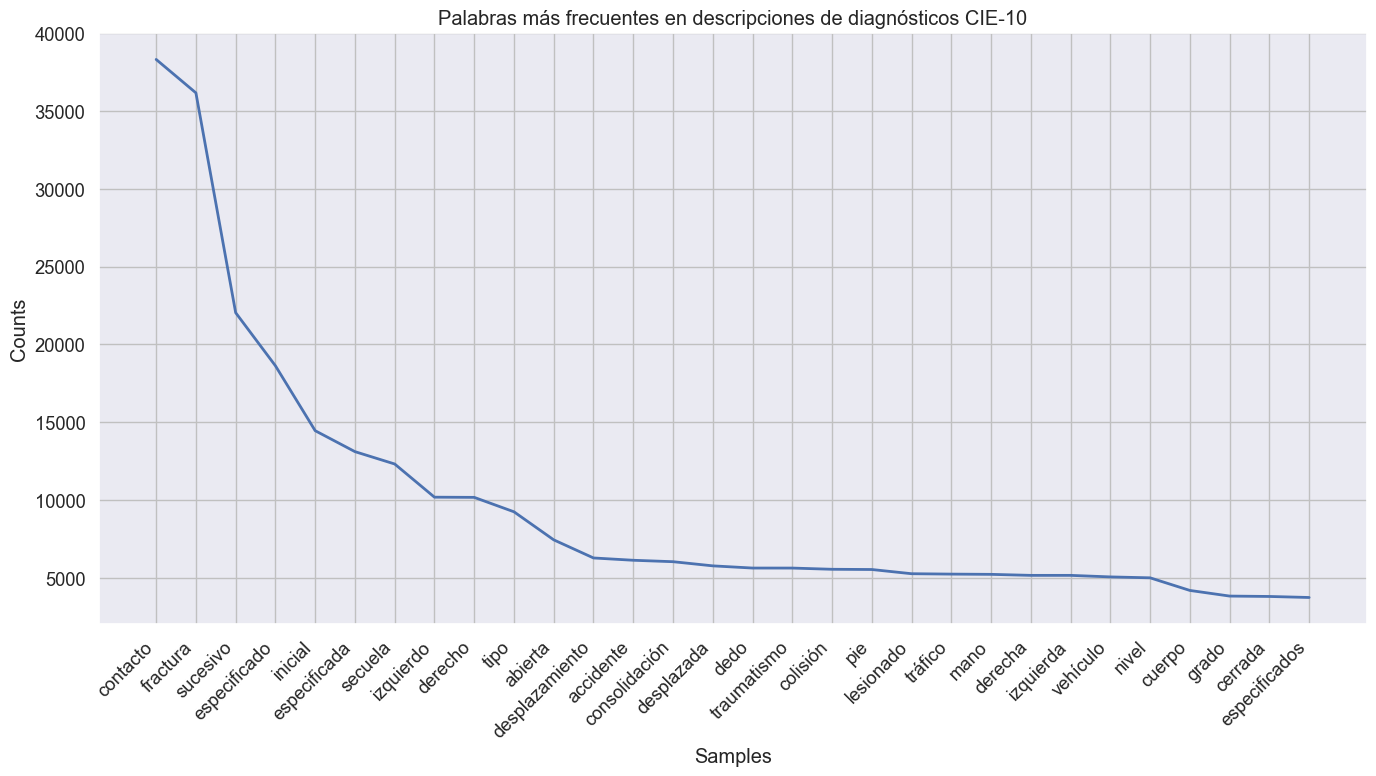

In [26]:
# Analizamos las descripciones de los diagnósticos CIE-10
if 'diagnosticos' in locals():
    # Aseguramos que la columna 'description' existe
    if 'description' in diagnosticos.columns:
        # Crear un corpus de todas las descripciones
        corpus_diagnosticos = ' '.join(diagnosticos['description'].fillna('').astype(str))

        # Tokenizar el corpus
        tokens_diagnosticos = obtener_tokens(corpus_diagnosticos)

        # Calcular frecuencia de palabras
        freq_dist = FreqDist(tokens_diagnosticos)

        # Visualizar las palabras más comunes
        plt.figure(figsize=(14, 8))
        freq_dist.plot(30, title="Palabras más frecuentes en descripciones de diagnósticos CIE-10")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        # Mostrar estadísticas
        print(f"Total de tokens únicos en diagnósticos: {len(set(tokens_diagnosticos))}")
        print(f"Total de tokens en diagnósticos: {len(tokens_diagnosticos)}")

        # Las 20 palabras más comunes
        print("\n20 palabras más frecuentes en diagnósticos:")
        for word, freq in freq_dist.most_common(20):
            print(f"{word}: {freq}")
    else:
        print("La columna 'descripcion' no se encuentra en el dataframe de diagnósticos")

Total de tokens únicos en procedimientos: 1618
Total de tokens en procedimientos: 620614

20 palabras más frecuentes en procedimientos:
abordaje: 70935
percutáneo: 36545
abierto: 22916
endoscópico: 22849
dispositivo: 18251
sustituto: 17223
tejido: 14527
izquierda: 12562
derecha: 12468
autólogo: 12465
arteria: 12205
drenaje: 10603
derecho: 8865
izquierdo: 8706
articulación: 7074
vena: 6698
artificial: 6426
orificio: 6373
natural: 6373
sintético: 6236


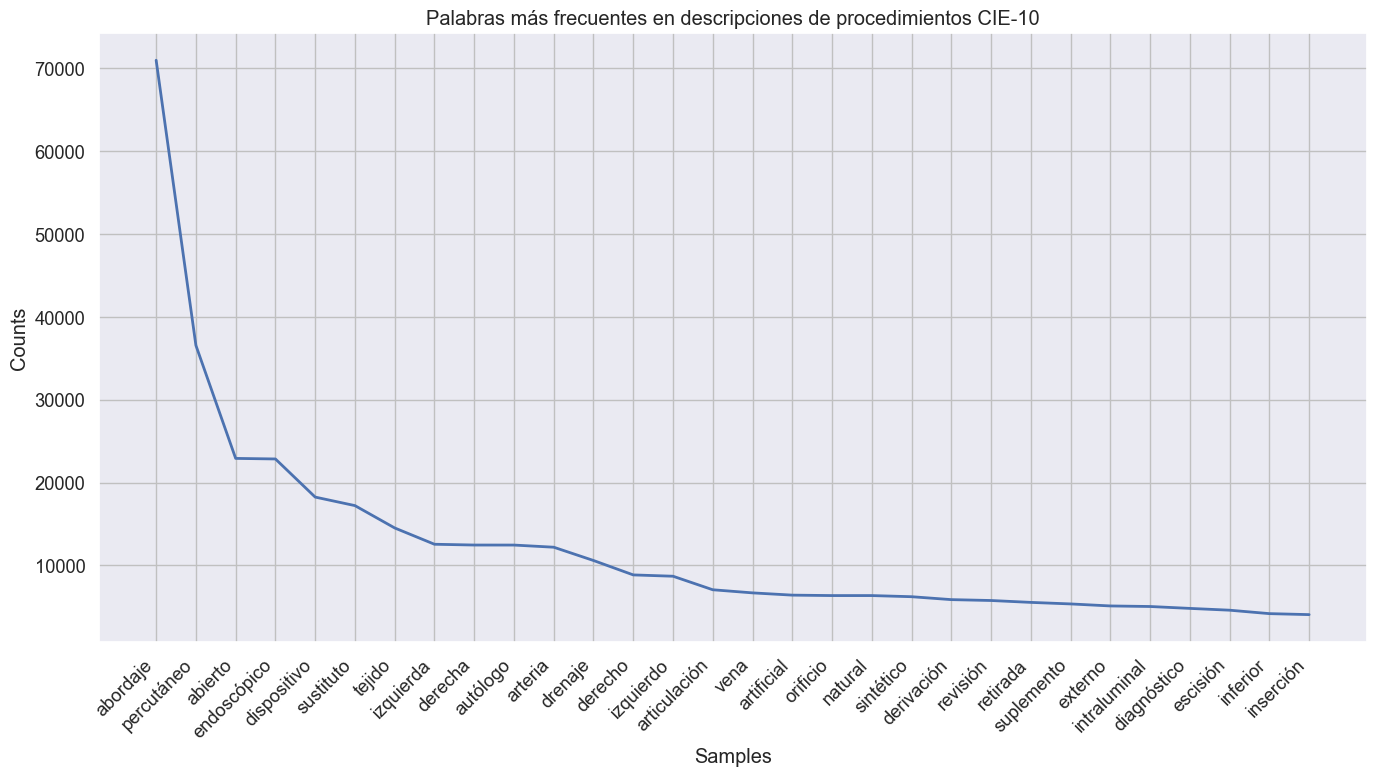

In [28]:
# Analizamos las descripciones de los procedimientos CIE-10
if 'procedimientos' in locals():
    # Aseguramos que la columna 'descripcion' existe
    if 'description' in procedimientos.columns:
        # Crear un corpus de todas las descripciones
        corpus_procedimientos = ' '.join(procedimientos['description'].fillna('').astype(str))

        # Tokenizar el corpus
        tokens_procedimientos = obtener_tokens(corpus_procedimientos)

        # Calcular frecuencia de palabras
        freq_dist_proc = FreqDist(tokens_procedimientos)

        # Visualizar las palabras más comunes
        plt.figure(figsize=(14, 8))
        freq_dist_proc.plot(30, title="Palabras más frecuentes en descripciones de procedimientos CIE-10")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        # Mostrar estadísticas
        print(f"Total de tokens únicos en procedimientos: {len(set(tokens_procedimientos))}")
        print(f"Total de tokens en procedimientos: {len(tokens_procedimientos)}")

        # Las 20 palabras más comunes
        print("\n20 palabras más frecuentes en procedimientos:")
        for word, freq in freq_dist_proc.most_common(20):
            print(f"{word}: {freq}")
    else:
        print("La columna 'descripcion' no se encuentra en el dataframe de procedimientos")


20 bigramas más frecuentes en diagnósticos:
contacto sucesivo: 22037
contacto inicial: 14436
sucesivo fractura: 11742
fractura abierta: 6162
consolidación fractura: 5665
abierta tipo: 5134
accidente tráfico: 4985
izquierdo contacto: 4796
derecho contacto: 4794
especificado contacto: 4723
inicial fractura: 4104
lesionado colisión: 3851
fractura cerrada: 3813
cuerpo extraño: 3530
fractura desplazada: 3038
fractura desplazamiento: 3037
curas rutinarias: 3027
retardo consolidación: 3027
fracaso consolidación: 3009
tipo i: 2928

Bigramas más asociados en diagnósticos (PMI):
arruga gliosis: 17.3202
buques mercantes: 17.3202
coriones amnios: 17.3202
fibroplasia retrocristalina: 17.3202
foster kennedy: 17.3202
frutas verduras: 17.3202
glomerulonefrosis intracapilar: 17.3202
hélice rotante: 17.3202
kayser fleischer: 17.3202
kearns sayre: 17.3202
lennox gastaut: 17.3202
meralgia parestésica: 17.3202
ora serrata: 17.3202
situs inversus: 17.3202
socavón corrimiento: 17.3202

Bigramas más asociado

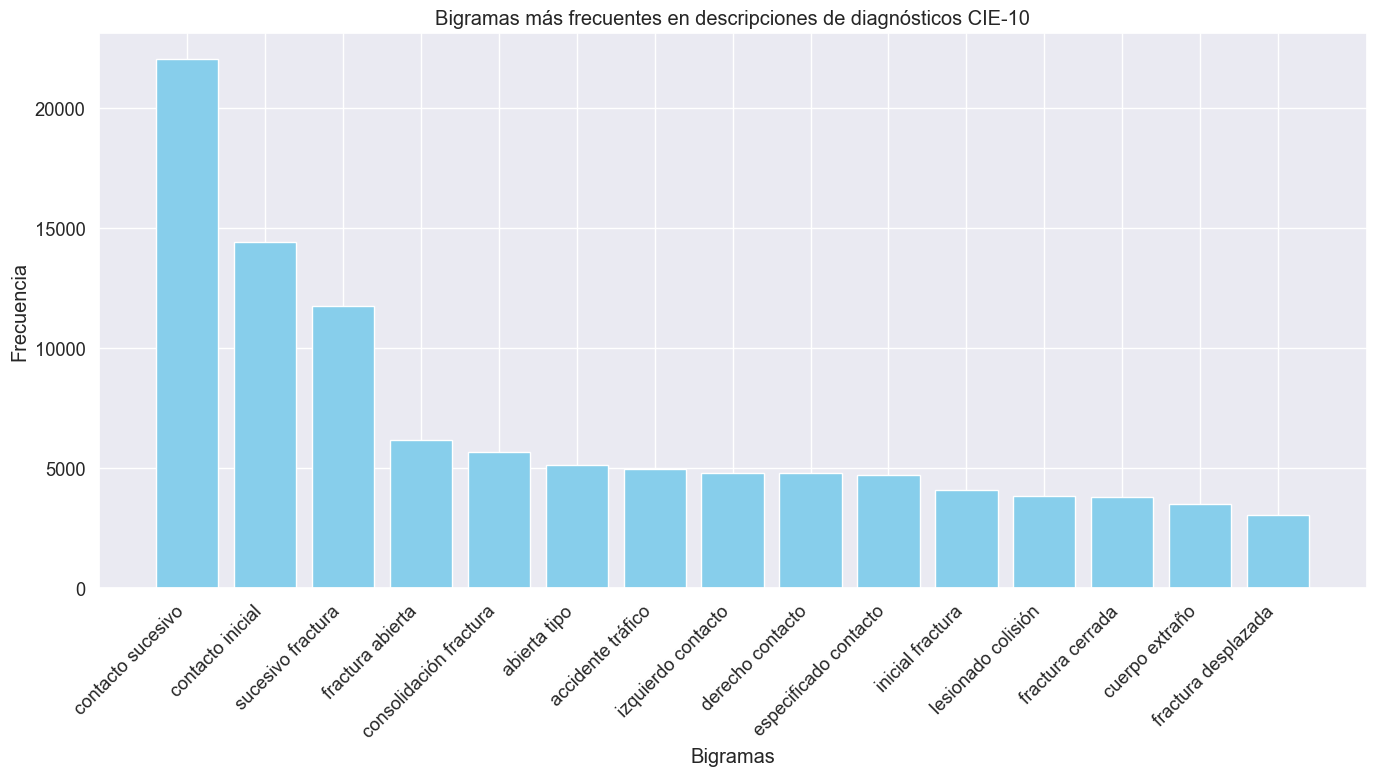

In [29]:
# Análisis de N-gramas en los diagnósticos
if 'tokens_diagnosticos' in locals():
    # Obtener bigramas (pares de palabras)
    bigramas_diagnosticos = list(ngrams(tokens_diagnosticos, 2))

    # Calcular frecuencia de bigramas
    freq_bigramas = FreqDist(bigramas_diagnosticos)

    # Mostrar los bigramas más comunes
    print("\n20 bigramas más frecuentes en diagnósticos:")
    for bigram, freq in freq_bigramas.most_common(20):
        print(f"{bigram[0]} {bigram[1]}: {freq}")

    # Visualizar los bigramas más comunes en un gráfico de barras
    bigramas_top = freq_bigramas.most_common(15)
    bigrama_labels = [f"{bg[0][0]} {bg[0][1]}" for bg in bigramas_top]
    bigrama_counts = [count for _, count in bigramas_top]

    plt.figure(figsize=(14, 8))
    plt.bar(bigrama_labels, bigrama_counts, color='skyblue')
    plt.title("Bigramas más frecuentes en descripciones de diagnósticos CIE-10")
    plt.xlabel("Bigramas")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Medidas de asociación entre palabras usando PMI (Pointwise Mutual Information)
    bigram_measures = BigramAssocMeasures()
    finder = BigramCollocationFinder.from_words(tokens_diagnosticos)

    # Filtrar bigramas con frecuencia mínima de 5
    finder.apply_freq_filter(5)

    # Obtener los bigramas más asociados según PMI
    print("\nBigramas más asociados en diagnósticos (PMI):")
    for bigram, score in finder.score_ngrams(bigram_measures.pmi)[:15]:
        print(f"{bigram[0]} {bigram[1]}: {score:.4f}")

## 3. Análisis de Estructura Jerárquica de Códigos

En esta sección analizaremos las relaciones jerárquicas entre los códigos CIE-10.

In [30]:
# Funciones para analizar la jerarquía de códigos CIE-10
def extraer_codigo_padre(codigo):
    """
    Extrae el código padre basado en la estructura jerárquica de CIE-10
    - Para códigos de categoría (ej: A00): retorna el capítulo (ej: A)
    - Para códigos de 4 caracteres (ej: A00.1): retorna la categoría (ej: A00)
    - Para códigos de 5 caracteres (ej: A00.11): retorna el código de 4 caracteres (ej: A00.1)
    """
    if not isinstance(codigo, str):
        return None

    # Limpiamos el código de espacios
    codigo = codigo.strip()

    # Patrón para códigos de categoría (3 caracteres: letra + 2 números)
    if re.match(r'^[A-Z]\d{2}$', codigo):
        return codigo[0]  # Devuelve solo la letra (capítulo)

    # Patrón para códigos de 4 caracteres (letra + 2 números + punto + 1 número)
    elif re.match(r'^[A-Z]\d{2}\.\d$', codigo):
        return codigo[:3]  # Devuelve la categoría (sin el punto y subcategoría)

    # Patrón para códigos de 5 caracteres (letra + 2 números + punto + 2 números)
    elif re.match(r'^[A-Z]\d{2}\.\d{2}$', codigo):
        return codigo[:5]  # Devuelve el código de 4 caracteres

    # Patrón para códigos de categoría con punto (A00.)
    elif re.match(r'^[A-Z]\d{2}\.$', codigo):
        return codigo[0]  # Devuelve solo la letra (capítulo)

    return None

def construir_grafo_jerarquia(df, columna_codigo='codigo'):
    """
    Construye un grafo de jerarquía basado en los códigos CIE-10
    """
    if columna_codigo not in df.columns:
        print(f"La columna {columna_codigo} no existe en el dataframe")
        return None

    # Creamos un grafo dirigido
    G = nx.DiGraph()

    # Añadimos los nodos con sus atributos
    for _, row in df.iterrows():
        codigo = row[columna_codigo]
        if isinstance(codigo, str):
            descripcion = row.get('descripcion', '')
            G.add_node(codigo, descripcion=descripcion)

    # Añadimos las aristas basadas en las relaciones jerárquicas
    for _, row in df.iterrows():
        codigo = row[columna_codigo]
        if isinstance(codigo, str):
            padre = extraer_codigo_padre(codigo)
            if padre and padre != codigo:  # Evitamos auto-lazos
                G.add_edge(padre, codigo)

    return G

Columnas en el dataframe de diagnósticos: ['code', 'description', 'perinatal', 'pediatric', 'maternity', 'adult', 'poaExempt', 'noPrincipal', 'exclusiveGender', 'vcdp']
Utilizando la columna 'code' para construir el grafo
Estadísticas del grafo de jerarquía para diagnósticos:
Número de nodos (códigos): 101272
Número de aristas (relaciones jerárquicas): 25295
Profundidad máxima de la jerarquía: 3
Camino más largo: A -> A27 -> A27.8 -> A27.81

Códigos con mayor número de subcódigos directos:
S (Sin descripción): 99 subcódigos
V (Sin descripción): 98 subcódigos
R (Sin descripción): 89 subcódigos
Z (Sin descripción): 89 subcódigos
C (Sin descripción): 88 subcódigos
Q (Sin descripción): 87 subcódigos
A (Sin descripción): 85 subcódigos
N (Sin descripción): 85 subcódigos
D (Sin descripción): 84 subcódigos
B (Sin descripción): 82 subcódigos
Estadísticas del grafo de jerarquía para diagnósticos:
Número de nodos (códigos): 101272
Número de aristas (relaciones jerárquicas): 25295
Profundidad máxi

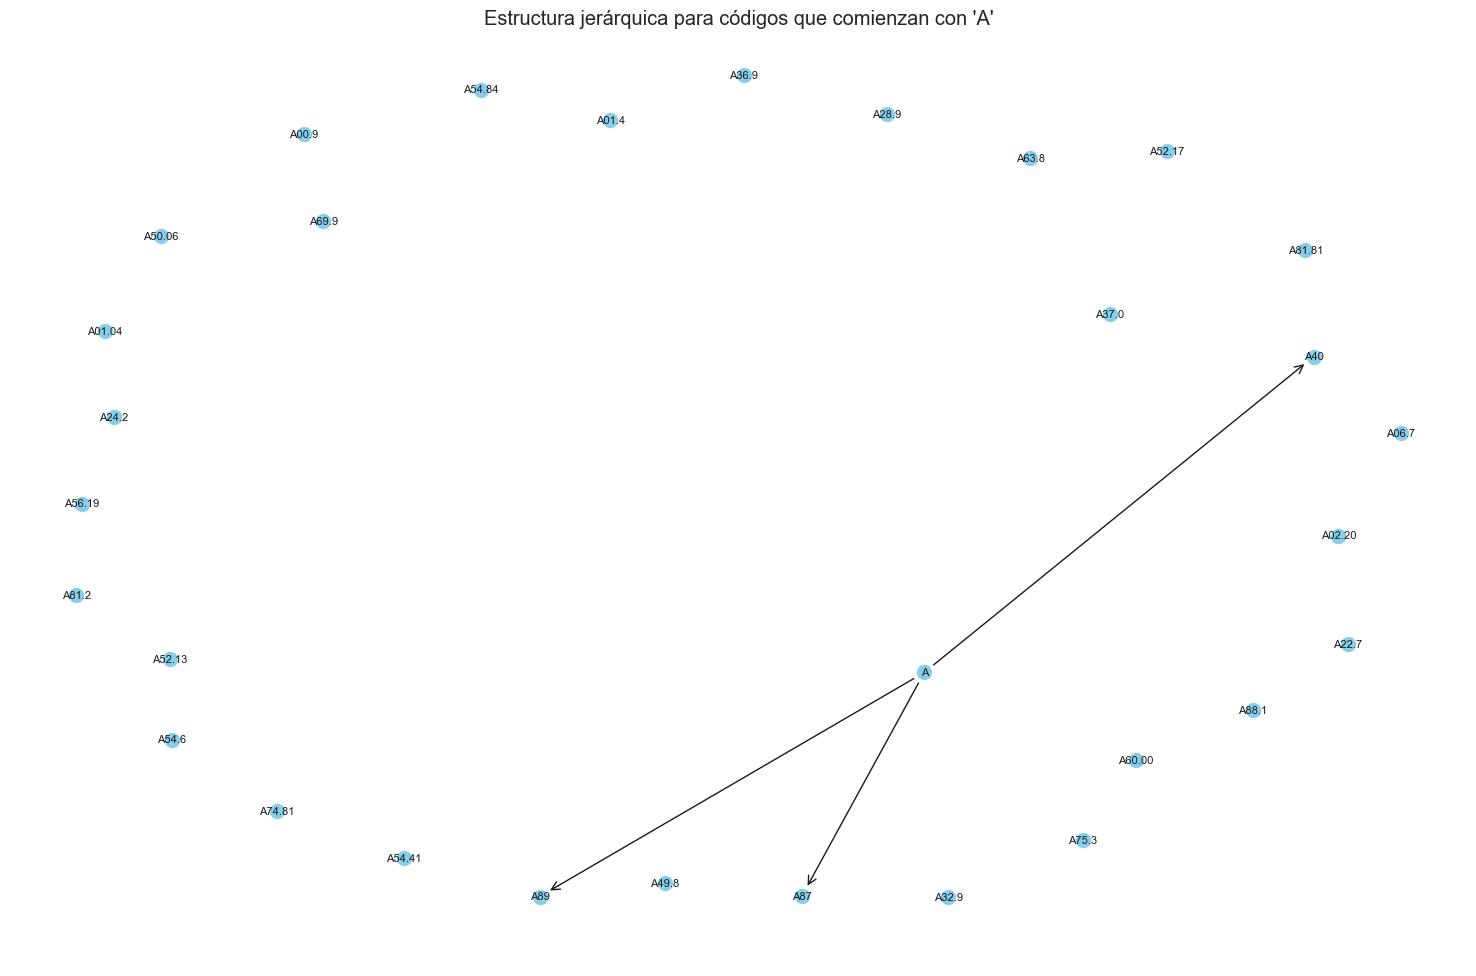

In [33]:
# Construimos y analizamos el grafo de jerarquía para diagnósticos
if 'diagnosticos' in locals():
    # Verificamos las columnas disponibles y el nombre correcto de la columna con los códigos
    print("Columnas en el dataframe de diagnósticos:", diagnosticos.columns.tolist())

    # Determinamos el nombre de la columna que contiene los códigos
    columna_codigo = "code"

    if columna_codigo:
        print(f"Utilizando la columna '{columna_codigo}' para construir el grafo")
        # Construir el grafo
        G_diagnosticos = construir_grafo_jerarquia(diagnosticos, columna_codigo)
    else:
        print("No se encontró una columna de códigos. Mostrando primeras filas del dataframe:")
        print(diagnosticos.head())
        G_diagnosticos = None

    if G_diagnosticos:
        # Estadísticas básicas del grafo
        print("Estadísticas del grafo de jerarquía para diagnósticos:")
        print(f"Número de nodos (códigos): {G_diagnosticos.number_of_nodes()}")
        print(f"Número de aristas (relaciones jerárquicas): {G_diagnosticos.number_of_edges()}")

        # Calcular la profundidad del árbol (longitud del camino más largo)
        try:
            # Encontrar la longitud del camino más largo en el grafo
            longest_path = nx.dag_longest_path(G_diagnosticos)
            print(f"Profundidad máxima de la jerarquía: {len(longest_path) - 1}")
            print(f"Camino más largo: {' -> '.join(longest_path)}")
        except:
            print("No se pudo calcular la profundidad (el grafo puede tener ciclos)")

        # Calcular el grado (número de conexiones) para cada nodo
        grados = dict(G_diagnosticos.degree())
        grados_entrada = dict(G_diagnosticos.in_degree())
        grados_salida = dict(G_diagnosticos.out_degree())

        # Nodos con mayor número de hijos (mayor grado de salida)
        nodos_mas_hijos = sorted(grados_salida.items(), key=lambda x: x[1], reverse=True)[:10]
        print("\nCódigos con mayor número de subcódigos directos:")
        for codigo, num_hijos in nodos_mas_hijos:
            if num_hijos > 0:
                descripcion = diagnosticos.loc[diagnosticos[columna_codigo] == codigo, 'description'].values
                desc = descripcion[0] if len(descripcion) > 0 else "Sin descripción"
                print(f"{codigo} ({desc}): {num_hijos} subcódigos")

        # Visualización de un subgrafo para un código específico (ejemplo: 'A')
        codigo_raiz = 'A'  # Puedes cambiar a otro código de interés

        # Obtener todos los descendientes del código raíz
        descendientes = set()
        for node in G_diagnosticos.nodes():
            if node.startswith(codigo_raiz) and node != codigo_raiz:
                descendientes.add(node)

        # Limitar a un número manejable de nodos para visualización
        descendientes_limitados = list(descendientes)[:30]
        descendientes_limitados.append(codigo_raiz)

        # Crear subgrafo
        subgrafo = G_diagnosticos.subgraph(descendientes_limitados)

        # Visualizar el subgrafo
        plt.figure(figsize=(15, 10))
        pos = nx.spring_layout(subgrafo, seed=42)  # Posicionamiento

        # Dibujar nodos
        nx.draw_networkx_nodes(subgrafo, pos, node_size=100, node_color='skyblue')

        # Dibujar aristas
        nx.draw_networkx_edges(subgrafo, pos, arrows=True, arrowstyle='->', arrowsize=15)

        # Dibujar etiquetas
        nx.draw_networkx_labels(subgrafo, pos, font_size=8)

        plt.title(f"Estructura jerárquica para códigos que comienzan con '{codigo_raiz}'")
        plt.axis('off')
        plt.tight_layout()
else:
    print("El dataframe de diagnósticos no está disponible")

## 4. Análisis Comparativo de Estructura Lingüística entre Conjuntos de Datos

Comparamos las características lingüísticas entre CIE-10-ES y CODIESP para identificar diferencias y similitudes en el vocabulario y la estructura.

Estadísticas de textos CODIESP:
Total de tokens únicos: 15087
Total de tokens: 102333

20 palabras más frecuentes en CODIESP:
paciente: 1201
tratamiento: 822
mg: 731
años: 711
meses: 462
tras: 426
estudio: 407
días: 392
dl: 386
realizó: 386
exploración: 377
normal: 375
cm: 366
derecho: 364
izquierdo: 355
dolor: 355
l: 347
antecedentes: 335
día: 329
diagnóstico: 325


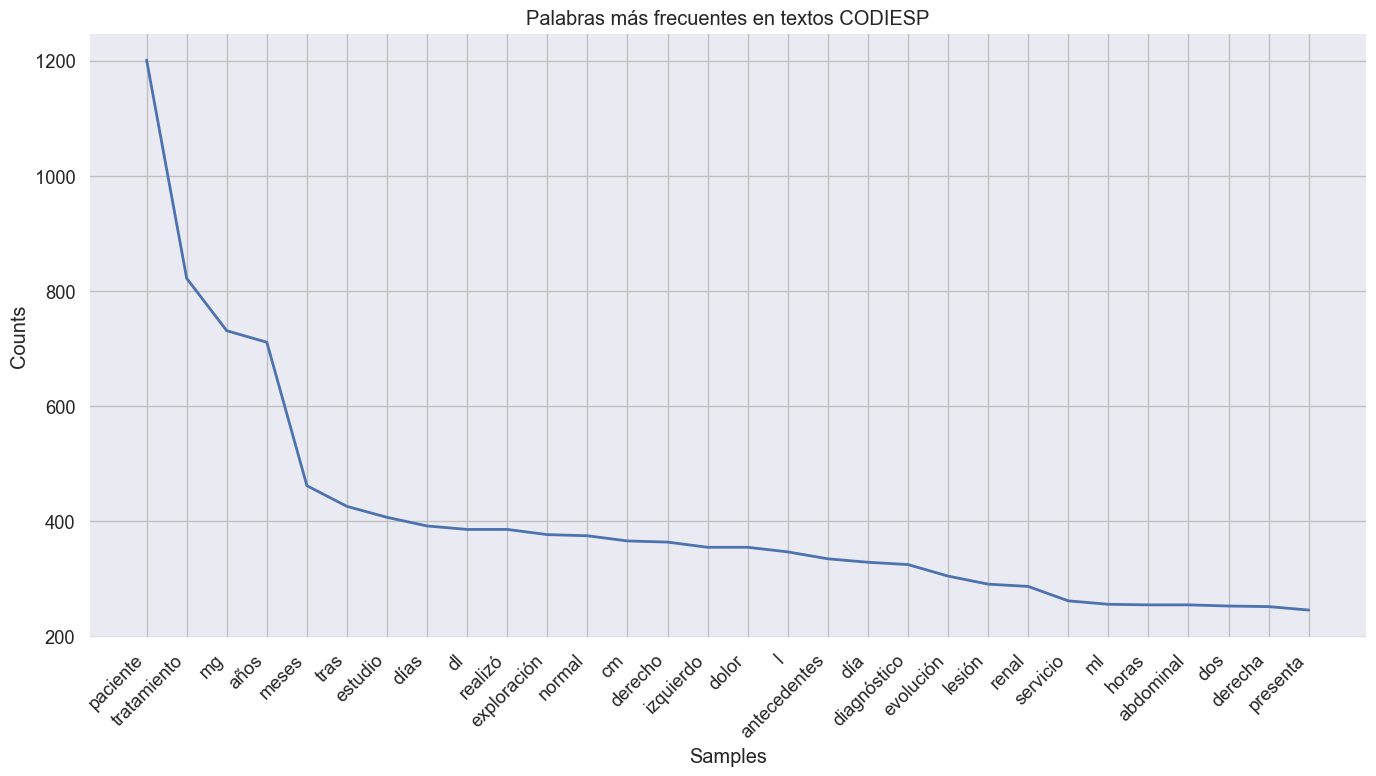

In [ ]:
# Preparación para análisis comparativo entre CIE-10 y CODIESP
# Extraemos textos de CODIESP para análisis lingüístico
if 'codiesp_d_train' in locals():
    if 'text' in codiesp_d_train.columns:
        # Crear corpus de textos CODIESP
        corpus_codiesp = ' '.join(codiesp_d_train['text'].fillna('').astype(str))

        # Tokenizar el corpus
        tokens_codiesp = obtener_tokens(corpus_codiesp)

        # Calcular frecuencia de palabras
        freq_dist_codiesp = FreqDist(tokens_codiesp)

        # Estadísticas básicas
        print("Estadísticas de textos CODIESP:")
        print(f"Total de tokens únicos: {len(set(tokens_codiesp))}")
        print(f"Total de tokens: {len(tokens_codiesp)}")

        # Las 20 palabras más comunes
        print("\n20 palabras más frecuentes en CODIESP:")
        for word, freq in freq_dist_codiesp.most_common(20):
            print(f"{word}: {freq}")

        # Visualizar las palabras más comunes
        plt.figure(figsize=(14, 8))
        freq_dist_codiesp.plot(30, title="Palabras más frecuentes en textos CODIESP")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
    else:
        print("La columna 'text' no se encuentra en el dataframe de CODIESP train")

In [ ]:
# Análisis comparativo de vocabulario entre CIE-10 y CODIESP
if all(var in locals() for var in ['tokens_diagnosticos', 'tokens_codiesp']):
    # Convertir listas de tokens a conjuntos para operaciones de conjunto
    vocab_diagnosticos = set(tokens_diagnosticos)
    vocab_codiesp = set(tokens_codiesp)

    # Calcular la intersección (palabras comunes)
    palabras_comunes = vocab_diagnosticos.intersection(vocab_codiesp)

    # Palabras únicas en cada conjunto
    unicas_diagnosticos = vocab_diagnosticos - vocab_codiesp
    unicas_codiesp = vocab_codiesp - vocab_diagnosticos

    # Mostrar estadísticas de comparación
    print("Comparación de vocabulario entre CIE-10 Diagnósticos y CODIESP:")
    print(f"Tamaño de vocabulario CIE-10: {len(vocab_diagnosticos)} palabras únicas")
    print(f"Tamaño de vocabulario CODIESP: {len(vocab_codiesp)} palabras únicas")
    print(f"Palabras comunes: {len(palabras_comunes)}")
    print(f"Palabras exclusivas de CIE-10: {len(unicas_diagnosticos)}")
    print(f"Palabras exclusivas de CODIESP: {len(unicas_codiesp)}")

    # Calcular coeficiente de Jaccard para medir la similitud
    jaccard = len(palabras_comunes) / len(vocab_diagnosticos.union(vocab_codiesp))
    print(f"Coeficiente de Jaccard: {jaccard:.4f}")

    # Visualización con diagrama de Venn
    plt.figure(figsize=(10, 6))
    venn2(subsets=(len(unicas_diagnosticos), len(unicas_codiesp), len(palabras_comunes)),
          set_labels=('CIE-10 Diagnósticos', 'CODIESP'))
    plt.title("Comparación de vocabulario entre CIE-10 y CODIESP")

    # Mostrar palabras más frecuentes en la intersección
    palabras_comunes_list = list(palabras_comunes)

    # Obtener las 20 palabras comunes más frecuentes en diagnósticos
    palabras_comunes_freq_diag = [(word, freq_dist[word]) for word in palabras_comunes_list if word in freq_dist]
    palabras_comunes_freq_diag = sorted(palabras_comunes_freq_diag, key=lambda x: x[1], reverse=True)[:20]

    print("\n20 palabras comunes más frecuentes en diagnósticos:")
    for word, freq in palabras_comunes_freq_diag:
        print(f"{word}: {freq}")

    # Crear gráfico de barras para comparar frecuencias en ambos conjuntos
    palabras_top_comunes = [word for word, _ in palabras_comunes_freq_diag[:10]]
    freq_diagnosticos = [freq_dist.get(word, 0) for word in palabras_top_comunes]
    freq_codiesp = [freq_dist_codiesp.get(word, 0) for word in palabras_top_comunes]

    # Normalizar frecuencias para una comparación justa
    if len(tokens_diagnosticos) > 0 and len(tokens_codiesp) > 0:
        freq_diagnosticos_norm = [freq / len(tokens_diagnosticos) * 10000 for freq in freq_diagnosticos]
        freq_codiesp_norm = [freq / len(tokens_codiesp) * 10000 for freq in freq_codiesp]

        # Crear dataframe para visualización
        df_comp = pd.DataFrame({
            'Palabra': palabras_top_comunes,
            'CIE-10 (por 10k palabras)': freq_diagnosticos_norm,
            'CODIESP (por 10k palabras)': freq_codiesp_norm
        })

        # Visualizar comparación
        plt.figure(figsize=(14, 8))
        df_comp.plot(x='Palabra', y=['CIE-10 (por 10k palabras)', 'CODIESP (por 10k palabras)'],
                    kind='bar', rot=45, ax=plt.gca())
        plt.title("Comparación de frecuencia de palabras comunes (normalizada)")
        plt.ylabel("Frecuencia por 10,000 palabras")
        plt.tight_layout()
else:
    print("No se puede realizar el análisis comparativo. Faltan los tokens de diagnósticos o CODIESP.")

No se puede realizar el análisis comparativo. Faltan los tokens de diagnósticos o CODIESP.


## 5. Análisis de Complejidad Lingüística

Analizamos la complejidad lingüística de las descripciones en ambos conjuntos de datos.

In [ ]:
# Funciones para análisis de complejidad lingüística
def calcular_estadisticas_texto(textos):
    """
    Calcula estadísticas lingüísticas para una lista de textos:
    - Longitud promedio de texto (en caracteres)
    - Número promedio de palabras por texto
    - Longitud promedio de palabra
    - Complejidad léxica (ratio de palabras únicas/total)
    """
    if not textos or all(not isinstance(t, str) for t in textos):
        return {
            "n_textos": 0,
            "longitud_promedio_texto": 0,
            "palabras_promedio": 0,
            "longitud_promedio_palabra": 0,
            "complejidad_lexica": 0
        }

    # Filtrar textos no válidos
    textos_validos = [t for t in textos if isinstance(t, str) and t.strip()]
    n_textos = len(textos_validos)

    if n_textos == 0:
        return {
            "n_textos": 0,
            "longitud_promedio_texto": 0,
            "palabras_promedio": 0,
            "longitud_promedio_palabra": 0,
            "complejidad_lexica": 0
        }

    # Longitud promedio de texto
    longitud_promedio_texto = sum(len(t) for t in textos_validos) / n_textos

    # Tokenizar todos los textos
    todos_tokens = []
    n_palabras_por_texto = []

    for texto in textos_validos:
        tokens = obtener_tokens(texto, eliminar_stopwords=False)
        todos_tokens.extend(tokens)
        n_palabras_por_texto.append(len(tokens))

    # Número promedio de palabras por texto
    palabras_promedio = sum(n_palabras_por_texto) / n_textos

    # Longitud promedio de palabra
    longitud_promedio_palabra = sum(len(token) for token in todos_tokens) / len(todos_tokens) if todos_tokens else 0

    # Complejidad léxica (ratio de palabras únicas/total)
    palabras_unicas = len(set(todos_tokens))
    total_palabras = len(todos_tokens)
    complejidad_lexica = palabras_unicas / total_palabras if total_palabras > 0 else 0

    return {
        "n_textos": n_textos,
        "longitud_promedio_texto": longitud_promedio_texto,
        "palabras_promedio": palabras_promedio,
        "longitud_promedio_palabra": longitud_promedio_palabra,
        "complejidad_lexica": complejidad_lexica
    }

In [ ]:
# Análisis de complejidad para diagnósticos CIE-10
resultados = {}

if 'diagnosticos' in locals() and 'descripcion' in diagnosticos.columns:
    descripciones_diagnosticos = diagnosticos['descripcion'].fillna('').astype(str).tolist()
    resultados['diagnosticos'] = calcular_estadisticas_texto(descripciones_diagnosticos)
    print("Estadísticas de complejidad para descripciones de diagnósticos CIE-10:")
    for metrica, valor in resultados['diagnosticos'].items():
        print(f"- {metrica}: {valor:.4f}")

# Análisis de complejidad para procedimientos CIE-10
if 'procedimientos' in locals() and 'descripcion' in procedimientos.columns:
    descripciones_procedimientos = procedimientos['descripcion'].fillna('').astype(str).tolist()
    resultados['procedimientos'] = calcular_estadisticas_texto(descripciones_procedimientos)
    print("\nEstadísticas de complejidad para descripciones de procedimientos CIE-10:")
    for metrica, valor in resultados['procedimientos'].items():
        print(f"- {metrica}: {valor:.4f}")

# Análisis de complejidad para textos CODIESP
if 'codiesp_d_train' in locals() and 'text' in codiesp_d_train.columns:
    textos_codiesp = codiesp_d_train['text'].fillna('').astype(str).tolist()
    resultados['codiesp'] = calcular_estadisticas_texto(textos_codiesp)
    print("\nEstadísticas de complejidad para textos CODIESP:")
    for metrica, valor in resultados['codiesp'].items():
        print(f"- {metrica}: {valor:.4f}")

# Visualización comparativa
if len(resultados) >= 2:
    # Preparar datos para gráfico
    metricas = ['longitud_promedio_texto', 'palabras_promedio', 'longitud_promedio_palabra', 'complejidad_lexica']
    datasets = list(resultados.keys())

    # Crear figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, metrica in enumerate(metricas):
        valores = [resultados[dataset][metrica] for dataset in datasets]
        axes[i].bar(datasets, valores, color=sns.color_palette("viridis", len(datasets)))
        axes[i].set_title(f'{metrica.replace("_", " ").capitalize()}')
        axes[i].set_ylabel('Valor')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.suptitle("Comparación de Complejidad Lingüística", fontsize=16, y=1.02)
    plt.show()


Estadísticas de complejidad para textos CODIESP:
- n_textos: 500.0000
- longitud_promedio_texto: 2317.2280
- palabras_promedio: 341.1600
- longitud_promedio_palabra: 5.5053
- complejidad_lexica: 0.0892


## 6. Análisis de Relación entre Complejidad Lingüística y Niveles Jerárquicos

Exploraremos cómo varía la complejidad lingüística según el nivel jerárquico en la estructura CIE-10.

In [ ]:
# Función para determinar el nivel jerárquico del código CIE-10
def determinar_nivel_jerarquico(codigo):
    """
    Determina el nivel jerárquico de un código CIE-10:
    - Nivel 1: Capítulo (solo letra, como 'A')
    - Nivel 2: Categoría (letra + 2 números, como 'A00')
    - Nivel 3: Subcategoría (letra + 2 números + punto + 1 número, como 'A00.1')
    - Nivel 4: Subclasificación (letra + 2 números + punto + 2 números, como 'A00.11')
    """
    if not isinstance(codigo, str):
        return 0

    codigo = codigo.strip()

    # Patrón para códigos de capítulo (solo letra)
    if re.match(r'^[A-Z]$', codigo):
        return 1

    # Patrón para códigos de categoría (letra + 2 números)
    elif re.match(r'^[A-Z]\d{2}$', codigo):
        return 2

    # Patrón para códigos de subcategoría (letra + 2 números + punto + 1 número)
    elif re.match(r'^[A-Z]\d{2}\.\d$', codigo):
        return 3

    # Patrón para códigos de subclasificación (letra + 2 números + punto + 2 números)
    elif re.match(r'^[A-Z]\d{2}\.\d{2}$', codigo):
        return 4

    # Otros patrones no estándar
    return 0

In [ ]:
# Analizamos la relación entre complejidad lingüística y nivel jerárquico
if 'diagnosticos' in locals() and 'codigo' in diagnosticos.columns and 'descripcion' in diagnosticos.columns:
    # Añadir columna de nivel jerárquico
    diagnosticos['nivel_jerarquico'] = diagnosticos['codigo'].apply(determinar_nivel_jerarquico)

    # Agrupar por nivel jerárquico
    datos_por_nivel = {}
    estadisticas_por_nivel = {}

    for nivel in range(1, 5):
        # Filtrar diagnósticos por nivel
        df_nivel = diagnosticos[diagnosticos['nivel_jerarquico'] == nivel]

        if not df_nivel.empty:
            # Obtener descripciones para este nivel
            descripciones = df_nivel['descripcion'].fillna('').astype(str).tolist()

            # Calcular estadísticas
            datos_por_nivel[nivel] = descripciones
            estadisticas_por_nivel[nivel] = calcular_estadisticas_texto(descripciones)

            print(f"\nEstadísticas para nivel jerárquico {nivel} (n={len(descripciones)}):")
            for metrica, valor in estadisticas_por_nivel[nivel].items():
                print(f"- {metrica}: {valor:.4f}")

    # Visualización de métricas por nivel jerárquico
    if estadisticas_por_nivel:
        metricas_a_visualizar = [
            'longitud_promedio_texto',
            'palabras_promedio',
            'longitud_promedio_palabra',
            'complejidad_lexica'
        ]

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        for i, metrica in enumerate(metricas_a_visualizar):
            niveles = list(estadisticas_por_nivel.keys())
            valores = [estadisticas_por_nivel[nivel][metrica] for nivel in niveles]

            axes[i].bar(niveles, valores, color=sns.color_palette("viridis", len(niveles)))
            axes[i].set_title(f'{metrica.replace("_", " ").capitalize()}')
            axes[i].set_xlabel('Nivel Jerárquico')
            axes[i].set_ylabel('Valor')
            axes[i].grid(axis='y', linestyle='--', alpha=0.7)
            axes[i].set_xticks(niveles)

        plt.tight_layout()
        plt.suptitle("Complejidad Lingüística por Nivel Jerárquico", fontsize=16, y=1.02)
        plt.show()

        # Análisis de correlación entre nivel jerárquico y métricas
        print("\nCorrelación entre nivel jerárquico y complejidad lingüística:")
        correlaciones = {}

        for metrica in metricas_a_visualizar:
            niveles = list(estadisticas_por_nivel.keys())
            valores = [estadisticas_por_nivel[nivel][metrica] for nivel in niveles]

            if len(niveles) > 1:  # Necesitamos al menos 2 puntos para calcular correlación
                corr = np.corrcoef(niveles, valores)[0, 1]
                correlaciones[metrica] = corr
                print(f"- {metrica}: {corr:.4f}")
else:
    print("No se puede realizar el análisis de niveles jerárquicos. Faltan datos necesarios.")

No se puede realizar el análisis de niveles jerárquicos. Faltan datos necesarios.
